# 🚀 DistilBERT Fine-Tuning

## Overview

This notebook fine-tunes the pretrained `distilbert-base-uncased` transformer model for multi-class mental health text classification.

Workflow:

- Load the Kaggle dataset from a local project directory
- Clean text data
- Encode labels
- Create Hugging Face Dataset objects
- Tokenize text using Hugging Face AutoTokenizer
- Fine-tune DistilBERT using the Trainer API
- Evaluate model performance
- Generate predictions and classification metrics


In [ ]:
# Local project paths
from pathlib import Path

# Assumes this notebook is run from the notebooks/ folder.
# If running from the repository root, change PROJECT_ROOT = Path.cwd()
PROJECT_ROOT = Path.cwd().parent

DATA_DIR = PROJECT_ROOT / "data"
RAW_DATA_DIR = DATA_DIR / "raw"
PROCESSED_DATA_DIR = DATA_DIR / "processed"
MODEL_DIR = PROJECT_ROOT / "models"
IMAGE_DIR = PROJECT_ROOT / "images"
REPORT_DIR = PROJECT_ROOT / "reports"

for directory in [RAW_DATA_DIR, PROCESSED_DATA_DIR, MODEL_DIR, IMAGE_DIR, REPORT_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

RAW_DATA_PATH = RAW_DATA_DIR / "raw_data.csv"

if not RAW_DATA_PATH.exists():
    print(f"Dataset not found at: {RAW_DATA_PATH}")
    print("Download the dataset from Kaggle and place raw_data.csv under data/raw/")
else:
    print(f"Using dataset: {RAW_DATA_PATH}")


# DistilBERT Model Training & Evaluation

In [ ]:
!pip install datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.5/491.5 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.6/193.6 kB 15.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 kB 15.6 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.5.0
    Uninstalling fsspec-2025.5.0:
      Successfully uninstalled fsspec-2025.5.0


In [ ]:
!pip install wandb

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.4/21.4 MB 135.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.6/207.6 kB 22.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 341.6/341.6 kB 35.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.8/62.8 kB 6.1 MB/s eta 0:00:00


In [ ]:
# imports
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nltk
from nltk.corpus import stopwords
from datasets import Dataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report
from transformers import AutoTokenizer, DistilBertForSequenceClassification, Trainer, TrainingArguments, pipeline, EarlyStoppingCallback

# disable login requirement for trainer
import wandb
wandb.init(mode="disabled")

In [ ]:
# load processed data

# Mount Google Drive

data_path = RAW_DATA_PATH
print("Data path set to:", data_path)

Mounted at /content/drive
Drive mounted successfully. Data path set to: /content/drive/MyDrive/MathForDeepLearning_Project/data/raw/raw_data.csv


In [ ]:
# load dataset into a dataframe
df = pd.read_csv(data_path)[['statement', 'status']].astype('str')
df.head()

,statement,status
0,oh my gosh,Anxiety
1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,I've shifted my focus to something else but I'...,Anxiety
4,"I'm restless and restless, it's been a month n...",Anxiety


In [ ]:
df.dropna(inplace=True)
#remove stopwords
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))
df['statement'] = df['statement'].astype(str).fillna('')
df['statement'] = df['statement'].apply(lambda x: ' '.join([word for word in x.split() if word.lower() not in stop_words]))
df.head()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


,statement,status
0,oh gosh,Anxiety
1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,"wrong, back dear, forward doubt. Stay restless...",Anxiety
3,shifted focus something else still worried,Anxiety
4,"restless restless, month now, boy. mean?",Anxiety


In [ ]:
# encode labels
le = LabelEncoder()
df['label'] = le.fit_transform(df['status']).astype('int')
df.head()
import pickle
# Ensure the folder exists
os.makedirs(str(MODEL_DIR / "distilbert_v1"), exist_ok=True)

# Now save the label encoder
save_path = str(MODEL_DIR / "distilbert_v1" / "label_encoder.pkl")
with open(save_path, "wb") as f:
    pickle.dump(le, f)


In [ ]:
le.classes_

array(['Anxiety', 'Bipolar', 'Depression', 'Normal',
       'Personality disorder', 'Stress', 'Suicidal'], dtype=object)

In [ ]:
# define class names
classes={0: 'Anxiety', 1: 'Bipolar', 2: 'Depression', 3: 'Normal', 4: 'Personality disorder', 5: 'Stress', 6: 'Suicidal'}

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53043 entries, 0 to 53042
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   statement  53043 non-null  object
 1   status     53043 non-null  object
 2   label      53043 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 1.2+ MB


In [ ]:
# create train, test, and validation sets
train_df, temp_df = train_test_split(df, test_size=0.2, random_state=12, stratify=df['label']) #ensure every class have equal proportion for model to learn
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=12, stratify=temp_df['label'])

In [ ]:
# convert dataframes to dataset class
train_dataset = Dataset.from_pandas(train_df, preserve_index=False)
test_dataset = Dataset.from_pandas(test_df, preserve_index=False)
val_dataset = Dataset.from_pandas(val_df, preserve_index=False)
train_dataset

Dataset({
    features: ['statement', 'status', 'label'],
    num_rows: 42434
})

In [ ]:
# load model
model_name = "distilbert-base-uncased"
num_labels = len(le.classes_)
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = DistilBertForSequenceClassification.from_pretrained(model_name, num_labels=num_labels, id2label=classes)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
# tokenize function
def tokenize(batch):
    return tokenizer(batch['statement'], padding=True, truncation=True, max_length=512)

In [ ]:
# tokenize
tokenized_train = train_dataset.map(tokenize, batched=True)
tokenized_test = test_dataset.map(tokenize, batched=True)

Map:   0%|          | 0/42434 [00:00<?, ? examples/s]

Map:   0%|          | 0/5305 [00:00<?, ? examples/s]

In [ ]:
# set format
tokenized_train.set_format('torch', columns=['input_ids', 'attention_mask', 'label'])
tokenized_test.set_format('torch', columns=['input_ids', 'attention_mask', 'label'])

In [ ]:
# define training arguments
training_args = TrainingArguments(
    output_dir=str(REPORT_DIR),
    num_train_epochs=4,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=1e-5,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    warmup_steps=500,
    lr_scheduler_type="cosine",
    load_best_model_at_end=True,
    report_to="wandb",
)

In [ ]:
# init trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_test,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

In [ ]:
# train
trainer.train()

wandb: WARNING The `run_name` is currently set to the same value as `TrainingArguments.output_dir`. If this was not intended, please specify a different run name by setting the `TrainingArguments.run_name` parameter.


Epoch,Training Loss,Validation Loss
1,0.808200,0.522397
2,0.481600,0.477601
3,0.390000,0.475242
4,0.343800,0.479304


TrainOutput(global_step=10612, training_loss=0.5059098733671198, metrics={'train_runtime': 987.3757, 'train_samples_per_second': 171.963, 'train_steps_per_second': 10.748, 'total_flos': 2.2486491272749056e+16, 'train_loss': 0.5059098733671198, 'epoch': 4.0})

In [ ]:
# evaluation
eval_results = trainer.evaluate()
print(f"Evaluation results: {eval_results}")

Evaluation results: {'eval_loss': 0.47524237632751465, 'eval_runtime': 1.3445, 'eval_samples_per_second': 1975.51, 'eval_steps_per_second': 61.735, 'epoch': 4.0}


In [ ]:
disbpredictons = trainer.predict(tokenized_test)
disbert_pred = disbpredictons.predictions.argmax(axis=-1)
disbert_true = test_df['label'].values
disbert_report = classification_report(disbert_true, disbert_pred)
print(disbert_report)

              precision    recall  f1-score   support

           0       0.88      0.84      0.86       389
           1       0.86      0.79      0.83       287
           2       0.80      0.76      0.78      1541
           3       0.95      0.95      0.95      1635
           4       0.64      0.70      0.67       120
           5       0.74      0.67      0.70       267
           6       0.70      0.78      0.74      1066

    accuracy                           0.82      5305
   macro avg       0.79      0.78      0.79      5305
weighted avg       0.83      0.82      0.82      5305



In [ ]:
# save
model.to('cpu')
model.save_pretrained("./mentalhealth_distilbert_classifier")
tokenizer.save_pretrained("./mentalhealth_distilbert_classifier")

('./mentalhealth_distilbert_classifier/tokenizer_config.json',
 './mentalhealth_distilbert_classifier/special_tokens_map.json',
 './mentalhealth_distilbert_classifier/vocab.txt',
 './mentalhealth_distilbert_classifier/added_tokens.json',
 './mentalhealth_distilbert_classifier/tokenizer.json')

In [ ]:
# classification pipeline
classifier = pipeline("text-classification", model="./mentalhealth_distilbert_classifier", tokenizer="./mentalhealth_distilbert_classifier")

Device set to use cpu


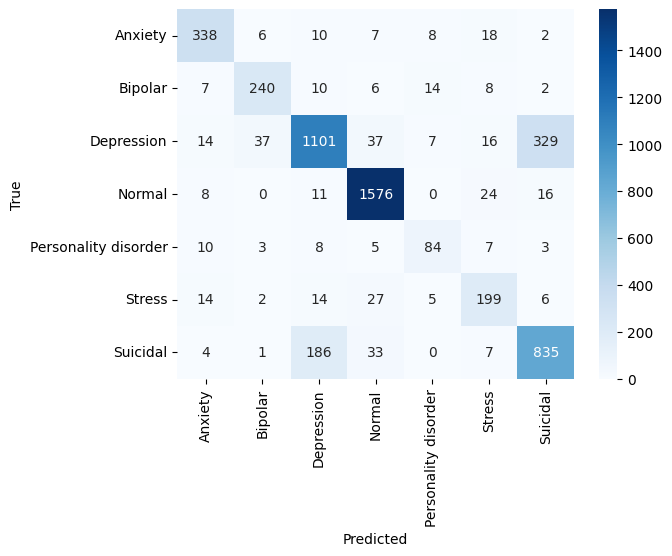

[[ 338    6   10    7    8   18    2]
 [   7  240   10    6   14    8    2]
 [  14   37 1101   37    7   16  329]
 [   8    0   11 1576    0   24   16]
 [  10    3    8    5   84    7    3]
 [  14    2   14   27    5  199    6]
 [   4    1  186   33    0    7  835]]


In [ ]:
# confusion matrix
import seaborn as sns
cm = confusion_matrix(disbert_true, disbert_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)

plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()
print(cm)

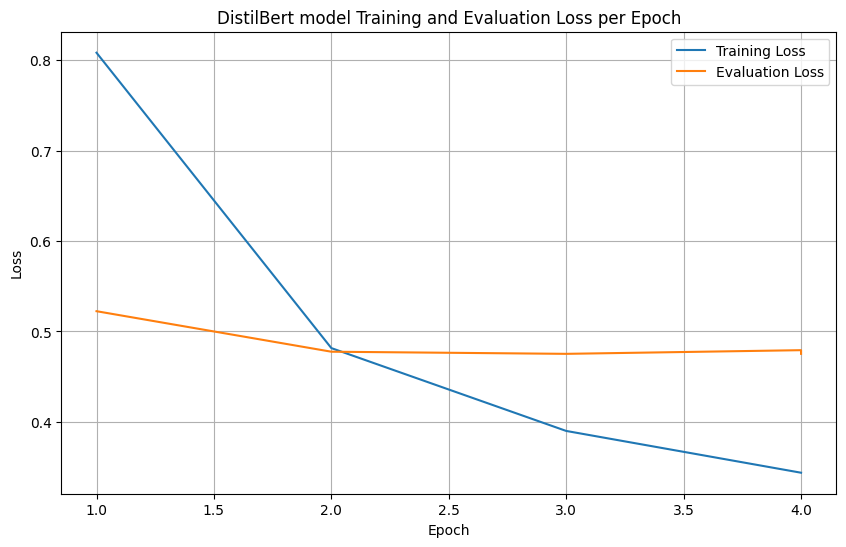

In [ ]:
import matplotlib.pyplot as plt

training_history = trainer.state.log_history

training_entries = [entry for entry in training_history if 'loss' in entry]
eval_entries = [entry for entry in training_history if 'eval_loss' in entry]

training_losses = [entry['loss'] for entry in training_entries]
training_epochs = [entry['epoch'] for entry in training_entries]
eval_losses = [entry['eval_loss'] for entry in eval_entries]
eval_epochs = [entry['epoch'] for entry in eval_entries]

plt.figure(figsize=(10, 6))
plt.plot(training_epochs, training_losses, label='Training Loss')
plt.plot(eval_epochs, eval_losses, label='Evaluation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('DistilBert model Training and Evaluation Loss per Epoch')
plt.legend()
plt.grid(True)
plt.show()

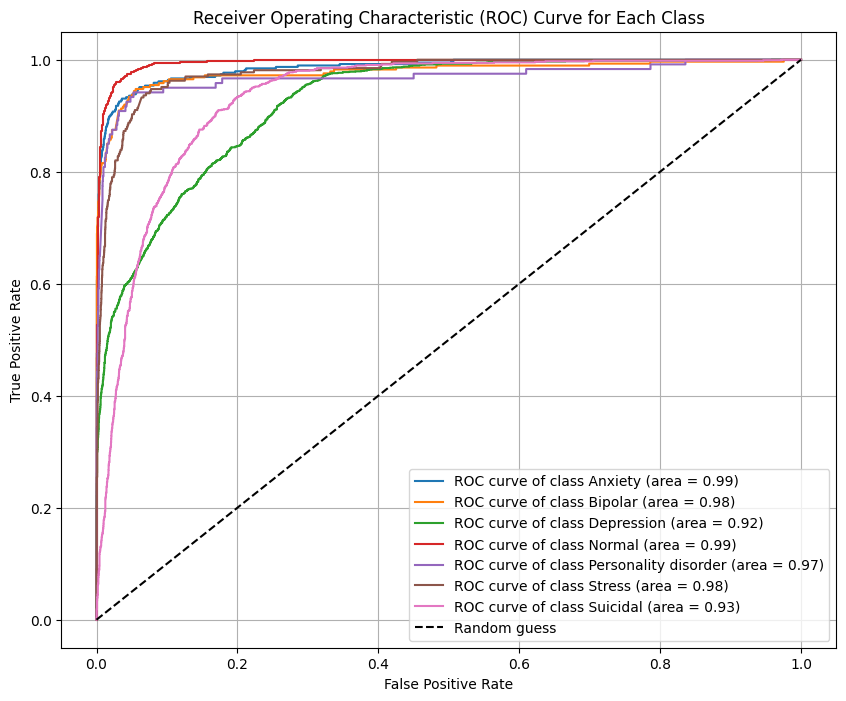

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

model.to('cpu')
model.save_pretrained("./mentalhealth_distilbert_classifier")
tokenizer.save_pretrained("./mentalhealth_distilbert_classifier")

model.to(trainer.args.device)

disb_pred_proba = trainer.predict(tokenized_test).predictions
y_true_binarized = label_binarize(disbert_true, classes=np.arange(num_labels))

fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(num_labels):
    fpr[i], tpr[i], _ = roc_curve(y_true_binarized[:, i], disb_pred_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(10, 8))
for i in range(num_labels):
    plt.plot(fpr[i], tpr[i], label='ROC curve of class {0} (area = {1:0.2f})'
                                   ''.format(le.classes_[i], roc_auc[i]))

plt.plot([0, 1], [0, 1], 'k--', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for Each Class')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

In [ ]:
# prediction function for testing
def predict_health():
  message = input("Input message: ").casefold()
  prediction = classifier(message)[0]
  print(prediction['label'])


In [ ]:
predict_health()

Input message: I feel incredibly happy and energetic one day, then completely drained and sad the next
Depression


In [ ]:
predict_health()

Input message: I don't feel like doing anything
Depression


In [ ]:
predict_health()

Input message: I stubbed my toe
Normal


In [ ]:
predict_health()

Input message: I feel like I'm two different people
Normal


In [ ]:
predict_health()

Input message: "I feel incredibly happy and energetic one day, then completely drained and sad the next
Depression


In [ ]:
!pip install transformers
!pip install torch

In [ ]:
!pip install tf.keras
!pip install tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 23.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 644.9/644.9 MB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 124.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 139.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 140.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 147.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.5/224.5 kB 21.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 6.1 MB/s eta 0:00:00
